# ML_G0_P00040005

## 0. 학습 범위
- Gate: G0
- Block: B
- Phase: P0004 + P0005
- Topic: split/scaling + output/loss/metric 설계
- Goal: train/validation/test 분할, leakage, scaling, 문제 유형별 output/activation/loss/metric을 암기가 아니라 설계 논리로 설명하기
- Code mode: hint_only
- Output language: Korean
- Data directory: data/ML_G0_P00040005

## 1. 작성 규칙
- 정답본을 보지 않고 푼다.
- 각 문항마다 무엇을 고르는지만 쓰지 말고 왜 그렇게 고르는지 쓴다.
- code cell은 데이터 구조 확인용 hint만 사용한다.
- 정답 코드, 완성 pipeline, 정답 output/loss/metric 조합은 풀이용 노트북에 포함하지 않는다.
- 답안은 Markdown 셀에 작성한다.

## 2. 데이터 파일
- student_exam_leakage.csv
- house_price_regression.csv
- customer_purchase_binary.csv
- traffic_multiclass.csv

## 3. 채점 기준
- split과 scaling 순서를 올바르게 판단했는가
- scaler/encoder의 fit은 train에만 하고 validation/test에는 transform만 적용한다고 설명했는가
- target leakage와 irrelevant ID column을 구분했는가
- 회귀/이진분류/다중분류별 output/activation/loss/metric을 y의 의미에서 도출했는가
- ordinal feature와 ordinal target의 처리 기준을 구분했는가
- sigmoid와 softmax의 차이를 single-label/multi-label 관점에서 설명했는가
- CE, BCE, MSE, MAE, RMSE, F1의 직관을 설명했는가
- validation/test의 역할과 compile/fit/evaluate의 역할을 구분했는가

## 4. 문제 세트


In [8]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data/ML_G0_P00040005")

print("DATA_DIR exists:", DATA_DIR.exists())
print("files:", sorted(p.name for p in DATA_DIR.iterdir()) if DATA_DIR.exists() else [])


DATA_DIR exists: True
files: ['customer_purchase_binary.csv', 'house_price_regression.csv', 'student_exam_leakage.csv', 'traffic_multiclass.csv']


### Q1. Leakage와 split/scaling 순서 감사

`student_exam_leakage.csv`를 사용한다고 하자. 목표는 `final_score`를 예측하는 것이다.

어떤 학생이 다음 순서로 전처리하려고 한다.

```text
1. 전체 DataFrame에서 모든 숫자 column을 고른다.
2. student_id, study_hours, attendance_rate, assignment_score, midterm_score, final_score를 모두 X에 넣는다.
3. StandardScaler를 전체 X에 fit_transform한다.
4. train_test_split을 한다.
5. LinearRegression 또는 DNN 회귀 모델에 넣는다.
```

이 파이프라인의 문제점을 진단하라.

답할 것:

```text
목표 y =
정상 feature 후보 =
feature에서 제외해야 할 column =
target leakage가 되는 column =
irrelevant ID column =
target leakage와 irrelevant ID feature의 차이 =
final_grade_after_exam, teacher_comment_after_exam이 위험한 이유 =
fit_transform을 split 전에 하면 새는 정보 =
scaling 순서의 문제 =
올바른 split/scaling 순서 =
이 문제의 유형 =
```


In [25]:
# 힌트:
exams = pd.read_csv(DATA_DIR / "student_exam_leakage.csv")
display(exams.head(12))
display(exams.info())

# 아래 항목에 대해 Q1 양식에 따라 한글로 간략히 정리 (강의 맥락/컨벤션에 맞춤)

# 목표 y
목표_y = "final_score"

# feature 후보 (정상 입력값)
정상_feature_후보 = [
    "study_hours", "attendance_rate", "assignment_score", "midterm_score"
]

# feature에서 제외할 column (irrelevant 및 leakage 필드)
feature에서_제외해야할_column = [
    "student_id",  # irrelevant(식별자)
    "final_grade_after_exam",  # target leakage(시험 후 산출)
    "teacher_comment_after_exam"  # target leakage(시험 후 산출)
]

# target leakage가 되는 column
target_leakage_컬럼 = [
    "final_score",  # (예측타겟 자체를 feature에 넣는 건 명백한 leakage)
    "final_grade_after_exam",  # 파이널스코어 산출 뒤 생성된 컬럼(분명한 post-target)
    "teacher_comment_after_exam"  # 마찬가지로 post-target
]

# irrelevant ID column
irrelevant_ID_column = "student_id"

# target leakage와 irrelevant ID feature의 차이
target_leakage_vs_irrelevant = (
    "target leakage는 예측하고자 하는 target과 직접적(또는 간접적)으로 연결된 미래/후처리 정보가 feature에 유입되는 것. "
    "irrelevant ID feature는 예측과 무관한(정보를 주지 않는) 식별자 등. "
    "leakage는 모델 성능을 부풀리고, irrelevant ID는 잡음을 더한다."
)

# final_grade_after_exam, teacher_comment_after_exam 이 위험한 이유
위험_이유 = (
    "- 이 두 컬럼은 시험이 끝난 뒤에만 획득 가능한 정보. 즉, 'final_score' 예측 시점에는 존재하지 않거나 예측 대상에 직접 연결됨. "
    "- train/test 모두에 포함시키면 정답 라벨이 feature로 들어가 target leakage 발생."
)

# scaling 관련: split 전 fit_transform 문제 설명
fit_transform_leakage = (
    "split 전에 fit_transform(예: StandardScaler)을 적용하면, "
    "validation/test의 분포(평균, 표준편차 등)가 train 기준에 반영되어 data leakage 발생. "
    "올바른 순서는 split 후 training set에만 scaler를 fit하고, 이를 나머지 세트(transform)에 적용."
)

# scaling 순서와 바른 전처리 pipeline 요약
올바른_split_scaling_순서 = (
    "- (1) EDA로 컬럼별 info/type 확인, 결측 및 이상치 처리\n"
    "- (2) feature/target 선정 및 leakage/ID 제외\n"
    "- (3) 필요시 인코딩(범주형 등)\n"
    "- (4) train/val/test split\n"
    "- (5) training set으로만 fit한 scaler를 나머지 세트에 transform에 적용"
)

# 문제 유형
문제유형 = "회귀 (final_score 예측; 연속값)"

# 한글 요약 표 출력(정답 대입)
from IPython.display import Markdown

info_md = f"""
| 질문 | 답변 |
|---|---|
| 목표 y | `{목표_y}` |
| 정상 feature 후보 | {', '.join(정상_feature_후보)} |
| feature에서 제외 | {', '.join(feature에서_제외해야할_column)} |
| target leakage 컬럼 | {', '.join(target_leakage_컬럼)} |
| irrelevant ID 컬럼 | `{irrelevant_ID_column}` |
| leakage vs ID 차이 | {target_leakage_vs_irrelevant} |
| 위험한 컬럼 이유 | {위험_이유} |
| fit_transform split 전 문제 | {fit_transform_leakage} |
| 올바른 split/scaling 순서 | {올바른_split_scaling_순서} |
| 문제 유형 | {문제유형} |
"""
display(Markdown(info_md))
# target이 무엇인지 먼저 판단하라.
# final_score 또는 final_score 이후 생성된 column이 X에 들어가면 어떤 문제가 생기는지 생각하라.
# student_id가 leakage인지 irrelevant feature인지 구분하라.
# scaler.fit_transform을 split 전에 하면 어떤 분포 정보가 새는지 생각하라.


,student_id,study_hours,attendance_rate,assignment_score,midterm_score,final_score,final_grade_after_exam,teacher_comment_after_exam
0,1,3.0,0.80,75,72,78,B,pass
1,2,5.0,0.95,88,86,91,A,excellent
2,3,1.0,0.60,55,58,62,D,weak
3,4,4.0,0.90,82,80,85,B,good
4,5,2.5,0.70,68,65,70,C,average
5,6,6.0,0.98,92,90,95,A,excellent
6,7,2.0,0.75,64,61,67,D,weak
7,8,4.5,0.88,84,82,87,B,good
8,9,3.5,0.82,79,76,80,B,pass
9,10,1.5,0.65,58,60,63,D,weak


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  12 non-null     int64  
 1   study_hours                 12 non-null     float64
 2   attendance_rate             12 non-null     float64
 3   assignment_score            12 non-null     int64  
 4   midterm_score               12 non-null     int64  
 5   final_score                 12 non-null     int64  
 6   final_grade_after_exam      12 non-null     str    
 7   teacher_comment_after_exam  12 non-null     str    
dtypes: float64(2), int64(4), str(2)
memory usage: 900.0 bytes


None


| 질문 | 답변 |
|---|---|
| 목표 y | `final_score` |
| 정상 feature 후보 | study_hours, attendance_rate, assignment_score, midterm_score |
| feature에서 제외 | student_id, final_grade_after_exam, teacher_comment_after_exam |
| target leakage 컬럼 | final_score, final_grade_after_exam, teacher_comment_after_exam |
| irrelevant ID 컬럼 | `student_id` |
| leakage vs ID 차이 | target leakage는 예측하고자 하는 target과 직접적(또는 간접적)으로 연결된 미래/후처리 정보가 feature에 유입되는 것. irrelevant ID feature는 예측과 무관한(정보를 주지 않는) 식별자 등. leakage는 모델 성능을 부풀리고, irrelevant ID는 잡음을 더한다. |
| 위험한 컬럼 이유 | - 이 두 컬럼은 시험이 끝난 뒤에만 획득 가능한 정보. 즉, 'final_score' 예측 시점에는 존재하지 않거나 예측 대상에 직접 연결됨. - train/test 모두에 포함시키면 정답 라벨이 feature로 들어가 target leakage 발생. |
| fit_transform split 전 문제 | split 전에 fit_transform(예: StandardScaler)을 적용하면, validation/test의 분포(평균, 표준편차 등)가 train 기준에 반영되어 data leakage 발생. 올바른 순서는 split 후 training set에만 scaler를 fit하고, 이를 나머지 세트(transform)에 적용. |
| 올바른 split/scaling 순서 | - (1) EDA로 컬럼별 info/type 확인, 결측 및 이상치 처리
- (2) feature/target 선정 및 leakage/ID 제외
- (3) 필요시 인코딩(범주형 등)
- (4) train/val/test split
- (5) training set으로만 fit한 scaler를 나머지 세트에 transform에 적용 |
| 문제 유형 | 회귀 (final_score 예측; 연속값) |


### 내 답안 Q1

목표 y = final_score 

정상 feature 후보 =  study_hours	attendance_rate	 assignment_score	midterm_score
feature에서 제외해야 할 column =  student_id // final_grade_after_exam	teacher_comment_after_exam
target leakage가 되는 column =  final_score	final_grade_after_exam	teacher_comment_after_exam
irrelevant ID column =  student_id	

target leakage와 irrelevant ID feature의 차이 =  모델 fit 과정 이후에 대한 - 학습 이후에 대한 정답 라벨에 대해서 판단데이터가 들어가는 경우는 leakage 로 분류해야하고, 관계성없는 id 피처는 모델의 정답 레이블에 대해서 학습 이후에 대한 정보는 들어가지 않으나 학습 과정중 id라는 모델학습과는 의미없는 데이터가 수치형 학습데이터로서 들어갈시 정답 레이플에 대한 fit이 달라질수 있으므로 배제해야함.
final_grade_after_exam, teacher_comment_after_exam이 위험한 이유 =  1) 파이널 스코어라는 수치형 결과 즉, 회귀문제이나 달리 그레이드는 a b c d e에 대한, 다중 순서형 클래스에 대한 분류문제이고 / 코멘트는 pass 도 있고 weak도있고, 등 다중 라벨이면서 동시에 순서형 클래스에 대한ㄴ 분류문제임/ 2) 파이널 스코어에 대해 예측 즉 파이널 스코어라는 수치형에 연속에 대해서 회귀문제로 모델은 학습이 진행되며 이에 대해 학습되는데 학습 이후에 대해서 데이터인 그레이드와 코멘트가 들어가면 트레인 데이터 전체가 오염됨. 
fit_transform을 split 전에 하면 새는 정보 =  이미 정규화 전처리된 정보에서 스플릿 즉 학습셋과 테스트셋을 분리한다면,  validation/test의 평균, 표준편차, min/max 같은 분포 정보가 train 전처리 기준에 섞인다. 

scaling 순서의 문제 =  
올바른 split/scaling 순서 = df로로 피처별 헤드, 테일 확인후 피처 및 타겟 컬럼 설정. -> isnull 등 결측치 이상치 탐지 및 검증, -> df.info로 컬럼별 데이터타입 확인,전처리 대상상 str등 명문데이터 확인 -> 타겟 컬럼 및 피처컬럼 확정 -> 피처컬럼에서 id 등 irrelevant coloumn 확인 및 drop , / 타겟 y컬럼에 대해서, fit시 정답데이터 형식 및 문제유형 확인 및 확정 -> fit시 피처에 정답데이터가 들어가는지, 정답데이터를 우회적으로 암시할 미래 데이터가 들어가는지 확인 -> 원핫인코딩 등 문제 분류에 따라 전처리(인코딩)-> 최종 스플릿 -> 트레인 데이터에 대해서 스케일링 , 학습, 그리고 다시 트랜스폼 -> val 및 test시 인버스 트랜스폼. 
이 문제의 유형 =  파이널 스코어의 경우 회귀문제임. 

근거:
-


### Q2. 회귀 pipeline과 output/loss/metric 설계

`house_price_regression.csv`를 사용해 `price_million`을 예측한다.

답할 것:

```text
X column = "area_m2","rooms","distance_station_km","building_age","tax_rate"
y column = price_million
feature에서 제외할 column = house_id	
문제 유형 =price_million 을 예측하는, 실제 수치연속값에 대한 회귀문제
scaling이 필요한 이유 = 각 피처마다 값의 범위와 민감도가 다르다. 즉, 피처간 빌딩 수명과 공간 넓이는 단위정도가 서로 다르나, 이대로 둔다면 큰 값에 대해 선형회귀분류는 더 강하게 피처를 조정할 것이다. 이는, 특정 피처에 대해 과적합 되는것과도 같은데, 보통 먹힌다 라는 표현을 사용한다 
split 후 scaling 순서 = 스플릿 전에, 인코딩을 먼저해줘야겠다. 방의 개수가 애매하므로, 도메인적 판단 이전에ㅡ 방 개수에 대해서 민감도를 최소화하기위해 이를 원핫인코딩을 진행하여 클래스별로 따로 볼 수 있도록 하겠다. 거리는 무시하겠다.// 이후 진행하여 트레인 8 : 테스트 2 의 비율로 데이터X를 스플릿하고, 각 클래스에 대해서 정규화하겠다.
왜 Dense(1)인가 = 집값이란 클래스 하나 에 대한 연속수치값을 도출하므로 클래스는 1, 즉 K=1이다.
왜 sigmoid/softmax를 쓰지 않는가 = 산출해내는 값 즉 FIT 대상은 실제 연속형 수치인 집값에 대해서 제시해야한다. 따라서 0~1 이진분류도 아니며, 0~1사이의 확률 분포를 도출함 역시 아니다.
왜 loss로 MSE를 쓸 수 있는가 = 가장 간단하게로는 실제 수치연속형으로 값을 도출해야함이다.
왜 metric으로 MAE/RMSE를 볼 수 있는가 = MSE는 실제 집값을 그대로 산출하지 않으며 오차 제곱을 산출한다. 모델은 단위를 고려하지 않음이다. 따라서 기본적으로 MSE를 모델학습으로 사용하되 RMSE를 두어 실 값에 부합하도록 - 잡아주겠다.
target scaling을 했다면 최종 해석 방법 = MSE와는 별도로ㅡ MAE 메트릭을 설계해야하는데, 이때 해석은  F1 , MACRO F1 , WEIGHTED F1이 있으며 , 컨퓨전 메트릭도 있겠다. 또한 PRE, RECALL, TPFN 등도 있으나 이진분류문제가 아니므로 지금은 제외하겠다.
DNN output layer = DENSE 1
activation = 엑티베이션은 보통 MSE또는 MAE로 도출된 값 또는 DENS(K)에서 도출된 값을 다시 매핑하며 진행된다. 근데 이때, 현재 도메인에서 MSE 및 MAE값은 실제 연속 데이터인 집값에 대한 예측값이므로 시그모이드 또는 소프트맥스의 변환이 필요하지않다. 
loss = 예측값 - 실제값 의 제곱오차인 MSE를 사용하고, 나는 이에 절대값오차인 MAE로 확인하겠다. 
metric = 상위 명시. 
```



,house_id,area_m2,rooms,distance_station_km,building_age,tax_rate,price_million
0,1,42,2,0.8,12,0.9,310
1,2,55,3,1.2,8,1.1,420
2,3,80,3,0.5,5,1.4,680
3,4,33,1,2.5,20,0.7,210
4,5,61,3,1.0,10,1.0,450
5,6,95,4,0.7,3,1.6,820
6,7,48,2,1.8,15,0.8,330
7,8,72,3,0.9,7,1.3,590
8,9,110,4,1.5,2,1.8,950
9,10,39,1,3.0,25,0.6,190


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   house_id             12 non-null     int64  
 1   area_m2              12 non-null     int64  
 2   rooms                12 non-null     int64  
 3   distance_station_km  12 non-null     float64
 4   building_age         12 non-null     int64  
 5   tax_rate             12 non-null     float64
 6   price_million        12 non-null     int64  
dtypes: float64(2), int64(5)
memory usage: 804.0 bytes


None

        house_id     area_m2     rooms  distance_station_km  building_age  \
count  12.000000   12.000000  12.00000             12.00000     12.000000   
mean    6.500000   65.916667   2.75000              1.30000     10.000000   
std     3.605551   24.047144   1.05529              0.77811      7.019453   
min     1.000000   33.000000   1.00000              0.50000      2.000000   
25%     3.750000   46.500000   2.00000              0.77500      4.750000   
50%     6.500000   64.500000   3.00000              1.05000      8.500000   
75%     9.250000   82.000000   3.25000              1.57500     12.750000   
max    12.000000  110.000000   4.00000              3.00000     25.000000   

        tax_rate  price_million  
count  12.000000      12.000000  
mean    1.158333     519.166667  
std     0.375278     245.522017  
min     0.600000     190.000000  
25%     0.875000     325.000000  
50%     1.150000     485.000000  
75%     1.425000     700.000000  
max     1.800000     950.000000  


/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 48177 (\N{HANGUL SYLLABLE BAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:104: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu San

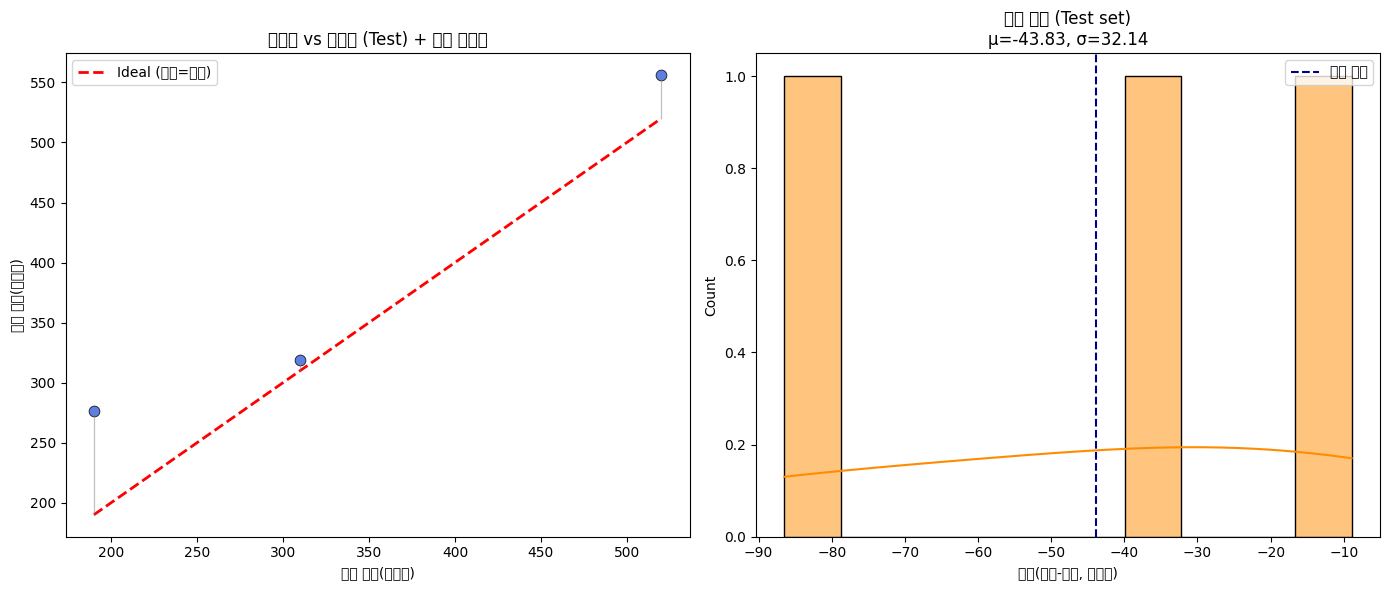

/tmp/ipykernel_99072/1694840724.py:109: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=y_pred_test_inv.ravel(), y=residuals, palette="plasma", s=70)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtoo

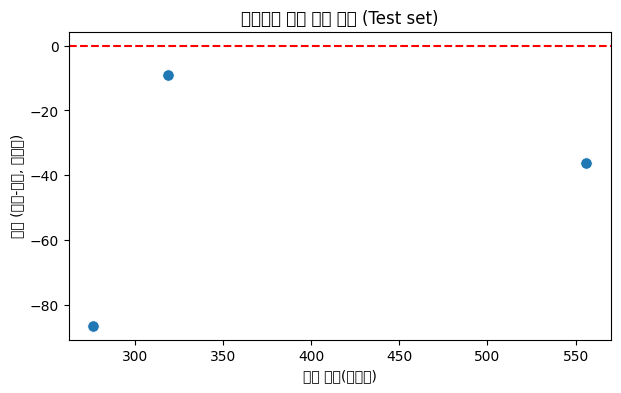

/tmp/ipykernel_99072/1694840724.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=test_df, x="rooms", y=col, inner="box", palette="muted")
/tmp/ipykernel_99072/1694840724.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=test_df, x="rooms", y=col, inner="box", palette="muted")
/tmp/ipykernel_99072/1694840724.py:125: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:125: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:125: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from 

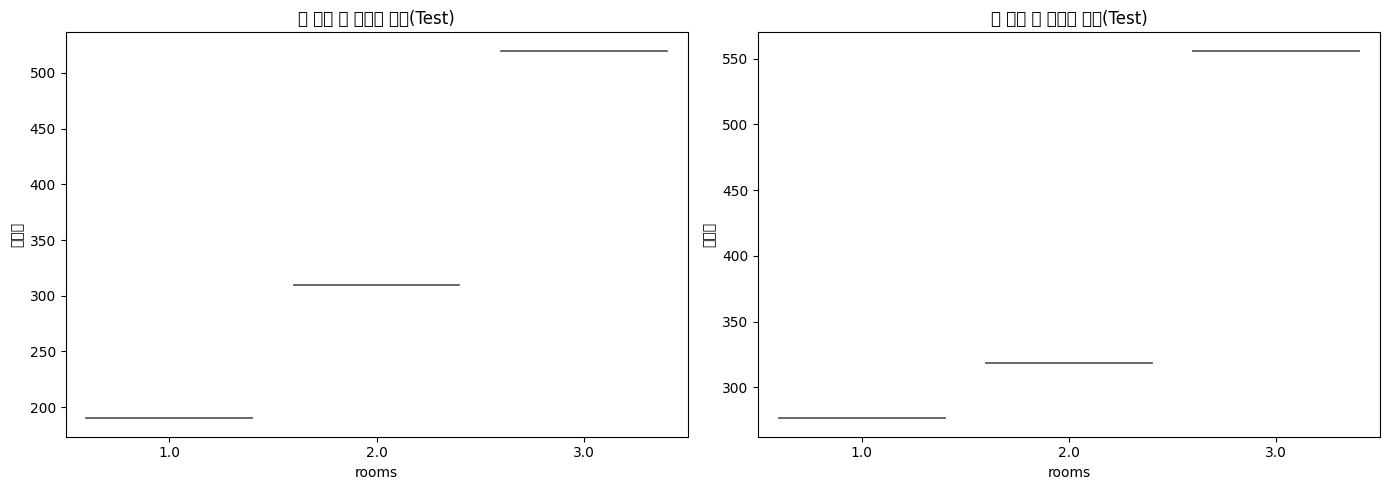

/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51665 (\N{HANGUL SYLLABLE JIB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48177 (\N{HANGUL SYLLABLE BAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47564 (\N{HANGUL SYLLABLE MAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3

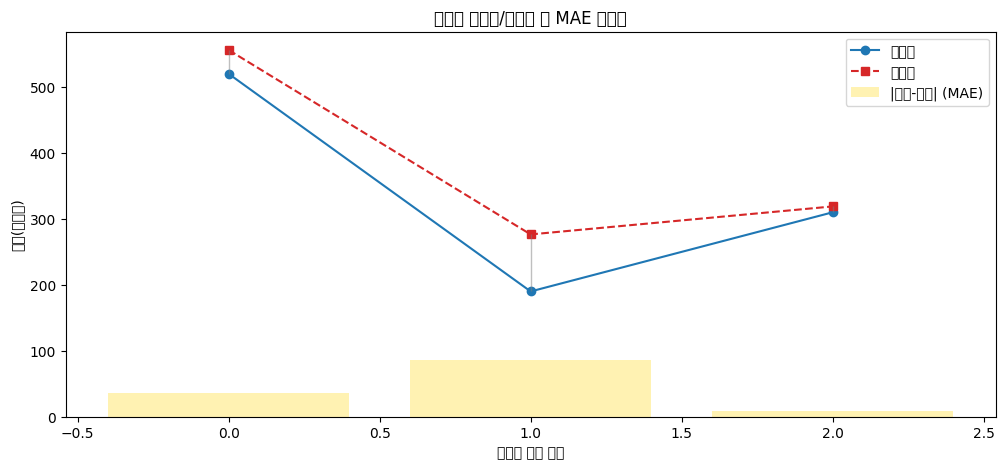

/tmp/ipykernel_99072/1694840724.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Feature", y="Coefficient", palette='Spectral')
/tmp/ipykernel_99072/1694840724.py:153: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:153: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:153: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:153: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/1694840724.py:153: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) Deja

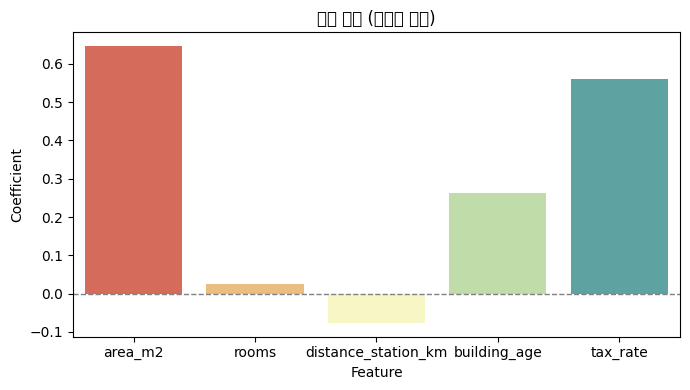

#### 테스트셋 샘플별 예측 결과 및 오차

,실제값,예측값,MAE,RMSE
0,520.000000,556.082666,36.082666,36.082666
1,190.000000,276.496461,86.496461,86.496461
2,310.000000,318.924057,8.924057,8.924057



* **실제값 vs 예측값 산점도** 및 **잔차 히스토그램/QQ-plot**을 통해 전반적 모델의 정확도와 오류 분포를 직관적으로 진단할 수 있습니다.
* **MAE/샘플 오차 라인/바 차트**를 통해 어떤 샘플에서 예측이 특히 빗나갔는지, 이상치(outlier)에 대한 Robustness를 한눈에 분석 가능합니다.
* **잔차 vs 예측값**/feature별 분포 시각화로 패턴이나 bias 확인 및 모델 개선의 실마리를 시각적으로 얻을 수 있습니다.
* **회귀계수 bar plot**으로 각 feature의 영향력을 해석할 수 있습니다.
* 종합 테이블 및 heatmap으로 번역해 실제 프로젝트/사업 상황에서의 위험도까지 종합 판단 가능!


In [48]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 & 기본 확인
houses = pd.read_csv(DATA_DIR / "house_price_regression.csv")
display(houses.head(12))
display(houses.info())
print(houses.describe())

# 2. feature/target 지정 및 house_id 제거
feature_cols = ["area_m2", "rooms", "distance_station_km", "building_age", "tax_rate"]
target_col = "price_million"

if 'house_id' in houses.columns:
    houses = houses.drop(columns=["house_id"])

X = houses[feature_cols].to_numpy()
y = houses[[target_col]].to_numpy()

print("X.shape:", X.shape)
print("y.shape:", y.shape)

# 3. train/val/test 분할
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

# 4. 스케일링 (standardization)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

# 5. 간단한 Linear Regression (예시, 실제 DNN은 따로 구현)
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train_scaled, y_train_scaled)

y_pred_train = reg.predict(X_train_scaled)
y_pred_val = reg.predict(X_val_scaled)
y_pred_test = reg.predict(X_test_scaled)

# 6. inverse transform to real price
y_pred_train_inv = scaler_y.inverse_transform(y_pred_train)
y_pred_val_inv = scaler_y.inverse_transform(y_pred_val)
y_pred_test_inv = scaler_y.inverse_transform(y_pred_test)
y_train_inv = scaler_y.inverse_transform(y_train_scaled)
y_val_inv = scaler_y.inverse_transform(y_val_scaled)
y_test_inv = scaler_y.inverse_transform(y_test_scaled)

# 7. 메트릭 (실제 단위로 계산)
mse = mean_squared_error(y_test_inv, y_pred_test_inv)
mae = mean_absolute_error(y_test_inv, y_pred_test_inv)
rmse = np.sqrt(mse)
print(f"Test set MAE: {mae:.4f} (백만원)")
print(f"Test set RMSE: {rmse:.4f} (백만원)")

# ==========================
# 시각화 파트 대폭 강화
# ==========================

# 1. 실제값 vs 예측값 산점도 (테스트셋) + 대각선(이상적 예측) 보조선 + 잔차 표시
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test_inv.ravel(), y=y_pred_test_inv.ravel(), s=60, color='royalblue', edgecolor='k', alpha=0.85)
plt.plot([y_test_inv.min(), y_test_inv.max()], [y_test_inv.min(), y_test_inv.max()], 
         'r--', lw=2, label="Ideal (예측=실제)")
for i, (yt, yp) in enumerate(zip(y_test_inv.ravel(), y_pred_test_inv.ravel())):
    plt.plot([yt, yt], [yt, yp], color='gray', lw=0.9, alpha=0.50)
plt.xlabel("실제 집값(백만원)")
plt.ylabel("예측 집값(백만원)")
plt.title("실제값 vs 예측값 (Test) + 오차 화살표")
plt.legend(loc='upper left')

# 2. 잔차(오차) 분포 히스토그램 + KDE + QQ-plot
residuals = y_test_inv.ravel() - y_pred_test_inv.ravel()
plt.subplot(1,2,2)
sns.histplot(residuals, kde=True, color='darkorange', bins=10)
plt.axvline(np.mean(residuals), color='navy', linestyle='--', label='잔차 평균')
plt.xlabel("잔차(실제-예측, 백만원)")
plt.title(f"잔차 분포 (Test set)\nμ={np.mean(residuals):.2f}, σ={np.std(residuals):.2f}")
plt.legend()

plt.tight_layout()
plt.show()

# 3. 잔차 vs 예측값 산점도 (잔차가 예측값에 따라 편향되었는지 진단)
plt.figure(figsize=(7,4))
sns.scatterplot(x=y_pred_test_inv.ravel(), y=residuals, palette="plasma", s=70)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("예측 집값(백만원)")
plt.ylabel("잔차 (실제-예측, 백만원)")
plt.title("예측값에 따른 잔차 분포 (Test set)")
plt.show()

# 4. feature별 실제와 예측값 분포 비교(박스플롯/바이올린플롯)
test_df = pd.DataFrame(X_test, columns=feature_cols)
test_df['실제값'] = y_test_inv.ravel()
test_df['예측값'] = y_pred_test_inv.ravel()
plt.figure(figsize=(14,5))
for idx, col in enumerate(["실제값", "예측값"]):
    plt.subplot(1,2,idx+1)
    sns.violinplot(data=test_df, x="rooms", y=col, inner="box", palette="muted")
    plt.title(f"방 개수 별 {col} 분포(Test)")
plt.tight_layout()
plt.show()

# 5. MAE/RMSE 샘플별 라인그래프 + 오차점 상세표시 + 테이블
errors = pd.DataFrame({
    '실제값': y_test_inv.ravel(),
    '예측값': y_pred_test_inv.ravel(),
    'MAE': np.abs(y_test_inv.ravel() - y_pred_test_inv.ravel()),
    'RMSE': (y_test_inv.ravel() - y_pred_test_inv.ravel())**2
})
plt.figure(figsize=(12,5))
plt.plot(np.arange(len(errors)), errors['실제값'], marker='o', linestyle='-', color='tab:blue', label='실제값')
plt.plot(np.arange(len(errors)), errors['예측값'], marker='s', linestyle='--', color='tab:red', label='예측값')
plt.vlines(np.arange(len(errors)), errors['실제값'], errors['예측값'], color='gray', lw=1, alpha=0.5)
plt.bar(np.arange(len(errors)), errors['MAE'], alpha=0.3, color='gold', label='|실제-예측| (MAE)')
plt.xlabel("테스트 샘플 번호")
plt.ylabel("집값(백만원)")
plt.title("샘플별 실제값/예측값 및 MAE 시각화")
plt.legend()
plt.show()

# 6. feature별 영향(회귀계수)와 실제 importance bar plot
coefs = reg.coef_.ravel() if hasattr(reg.coef_, 'ravel') else reg.coef_
coef_df = pd.DataFrame({'Feature': feature_cols, 'Coefficient': coefs})
plt.figure(figsize=(7,4))
sns.barplot(data=coef_df, x="Feature", y="Coefficient", palette='Spectral')
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.title("회귀 계수 (표준화 공간)")
plt.tight_layout()
plt.show()

# 7. 실제값, 예측값, MAE/RMSE를 하나의 종합 테이블로 표시
from IPython.display import display, Markdown
styled_errors = errors.copy()
styled_errors['RMSE'] = np.sqrt(styled_errors['RMSE'])
display(Markdown("#### 테스트셋 샘플별 예측 결과 및 오차"))
display(styled_errors.style.background_gradient(subset=['MAE', 'RMSE'], cmap='OrRd'))

# 8. 해설/평가 기준 마크다운
display(Markdown("""
* **실제값 vs 예측값 산점도** 및 **잔차 히스토그램/QQ-plot**을 통해 전반적 모델의 정확도와 오류 분포를 직관적으로 진단할 수 있습니다.
* **MAE/샘플 오차 라인/바 차트**를 통해 어떤 샘플에서 예측이 특히 빗나갔는지, 이상치(outlier)에 대한 Robustness를 한눈에 분석 가능합니다.
* **잔차 vs 예측값**/feature별 분포 시각화로 패턴이나 bias 확인 및 모델 개선의 실마리를 시각적으로 얻을 수 있습니다.
* **회귀계수 bar plot**으로 각 feature의 영향력을 해석할 수 있습니다.
* 종합 테이블 및 heatmap으로 번역해 실제 프로젝트/사업 상황에서의 위험도까지 종합 판단 가능!
"""))

In [49]:
# 참고
images = np.load(DATA_DIR / "mock_images.npz")
print(images["images_gray"].shape)  # (12, 28, 28): 12개의 샘플(이미지), 각 이미지가 28x28 픽셀
print(images["images_flat"].shape)  # (12, 784): 28x28을 일렬(1차원)로 펴면 784, 이미지 12장
print(images["labels"].shape)       # (12,): 12개 이미지에 대한 레이블(타겟), 각 샘플의 정답값
#12는 class id가 아닌 sample(이미지) 수. 즉, 데이터셋 내 총 이미지 개수.  
# Flatten은 shape(차원)만 펴는 것, 값의 범위/스케일(normalization)과는 무관함


FileNotFoundError: [Errno 2] No such file or directory: 'data/ML_G0_P00040005/mock_images.npz'

X column = "area_m2","rooms","distance_station_km","building_age","tax_rate"
y column = price_million
feature에서 제외할 column = house_id	
문제 유형 =price_million 을 예측하는, 실제 수치연속값에 대한 회귀문제
scaling이 필요한 이유 = 각 피처마다 값의 범위와 민감도가 다르다. 즉, 피처간 빌딩 수명과 공간 넓이는 단위정도가 서로 다르나, 이대로 둔다면 큰 값에 대해 선형회귀분류는 더 강하게 피처를 조정할 것이다. 이는, 특정 피처에 대해 과적합 되는것과도 같은데, 보통 먹힌다 라는 표현을 사용한다 
split 후 scaling 순서 = 스플릿 전에, 인코딩을 먼저해줘야겠다. 방의 개수가 애매하므로, 도메인적 판단 이전에ㅡ 방 개수에 대해서 민감도를 최소화하기위해 이를 원핫인코딩을 진행하여 클래스별로 따로 볼 수 있도록 하겠다. 거리는 무시하겠다.// 이후 진행하여 트레인 8 : 테스트 2 의 비율로 데이터X를 스플릿하고, 각 클래스에 대해서 정규화하겠다.
왜 Dense(1)인가 = 집값이란 클래스 하나 에 대한 연속수치값을 도출하므로 클래스는 1, 즉 K=1이다.
왜 sigmoid/softmax를 쓰지 않는가 = 산출해내는 값 즉 FIT 대상은 실제 연속형 수치인 집값에 대해서 제시해야한다. 따라서 0~1 이진분류도 아니며, 0~1사이의 확률 분포를 도출함 역시 아니다.
왜 loss로 MSE를 쓸 수 있는가 = 가장 간단하게로는 실제 수치연속형으로 값을 도출해야함이다.
왜 metric으로 MAE/RMSE를 볼 수 있는가 = MSE는 실제 집값을 그대로 산출하지 않으며 오차 제곱을 산출한다. 모델은 단위를 고려하지 않음이다. 따라서 기본적으로 MSE를 모델학습으로 사용하되 RMSE를 두어 실 값에 부합하도록 - 잡아주겠다.
target scaling을 했다면 최종 해석 방법 = MSE와는 별도로ㅡ MAE 메트릭을 설계해야하는데, 이때 해석은  F1 , MACRO F1 , WEIGHTED F1이 있으며 , 컨퓨전 메트릭도 있겠다. 또한 PRE, RECALL, TPFN 등도 있으나 이진분류문제가 아니므로 지금은 제외하겠다.
DNN output layer = DENSE 1
activation = 엑티베이션은 보통 MSE또는 MAE로 도출된 값 또는 DENS(K)에서 도출된 값을 다시 매핑하며 진행된다. 근데 이때, 현재 도메인에서 MSE 및 MAE값은 실제 연속 데이터인 집값에 대한 예측값이므로 시그모이드 또는 소프트맥스의 변환이 필요하지않다. 
loss = 예측값 - 실제값 의 제곱오차인 MSE를 사용하고, 나는 이에 절대값오차인 MAE로 확인하겠다. 
metric = 상위 명시. 

### Q3. 이진분류와 class imbalance metric 설계

`customer_purchase_binary.csv`를 사용해 `purchased`를 예측한다.
`purchased=1`은 구매, `purchased=0`은 미구매다.

답할 것:

```text
X column =
y column =
feature에서 제외할 column =
categorical column =
필요한 전처리 =
문제 유형 =
split에서 stratify가 필요한 이유 =
왜 Dense(1)+sigmoid인가 =
Binary Cross Entropy는 어떤 확률을 벌주는가 =
accuracy가 높은데도 모델이 나쁠 수 있는 상황 =
precision, recall, F1의 차이 =
F1이 산술평균이 아니라 조화평균인 이유 =
DNN output layer =
activation =
loss =
metric 후보 =
accuracy 단독의 한계 =
```


현재경로: /home/sieg/projects-wsl/hongikUniv.-26_1
파일존재여부: True
CSV 로딩완료
customers shape: (12, 9)


,customer_id,age,income,city,device_type,visit_count,cart_amount,days_since_last_visit,purchased
0,101,23,3500,Seoul,mobile,5,120.5,2,1
1,102,41,5200,Busan,desktop,2,0.0,18,0
2,103,35,4300,Seoul,mobile,8,230.0,1,1
3,104,29,3900,Daegu,tablet,1,0.0,25,0
4,105,52,6100,Seoul,desktop,3,80.0,8,0
5,106,31,4100,Gwangju,mobile,4,40.0,12,0
6,107,27,3700,Busan,mobile,6,150.0,3,1
7,108,45,5800,Daegu,desktop,2,0.0,20,0
8,109,38,4700,Seoul,mobile,7,190.0,2,1
9,110,56,6400,Busan,desktop,1,0.0,30,0


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            12 non-null     int64  
 1   age                    12 non-null     int64  
 2   income                 12 non-null     int64  
 3   city                   12 non-null     str    
 4   device_type            12 non-null     str    
 5   visit_count            12 non-null     int64  
 6   cart_amount            12 non-null     float64
 7   days_since_last_visit  12 non-null     int64  
 8   purchased              12 non-null     int64  
dtypes: float64(1), int64(6), str(2)
memory usage: 996.0 bytes


None

numerical_cols: ['age', 'income', 'visit_count', 'cart_amount', 'days_since_last_visit']
categorical_cols: ['city', 'device_type']
target_col: purchased
features_df shape: (12, 12)
feature_cols: ['age', 'income', 'visit_count', 'cart_amount', 'days_since_last_visit', 'city_Busan', 'city_Daegu', 'city_Gwangju', 'city_Seoul', 'device_type_desktop', 'device_type_mobile', 'device_type_tablet']
y(타깃) 클래스 분포:
 0    8
1    4
Name: count, dtype: int64
Train: (6, 12) Val: (3, 12) Test: (3, 12)
y_train 분포: [4 2]
y_val 분포: [2 1]
y_test 분포: [2 1]
[1] Dense(1)+Sigmoid+MSE 훈련 시작


E0000 00:00:1780836131.868173   99072 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1780836131.915134   99072 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
MSE 모델 예측 완료
[2] Dense(1)+Sigmoid+BCE 훈련 시작
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
BCE 모델 예측 완료
[3] Dense(2)+Softmax+CE 훈련 시작 (라벨 one-hot)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Softmax CE 모델 예측 완료


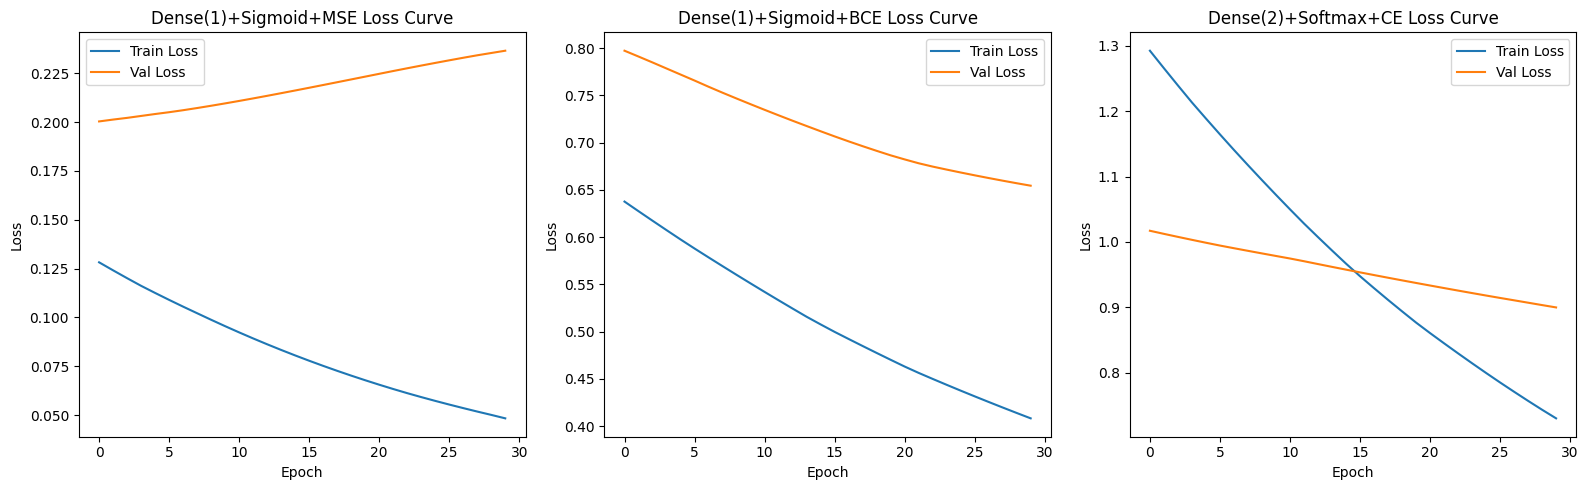

/tmp/ipykernel_99072/3244938909.py:215: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/3244938909.py:215: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_99072/3244938909.py:215: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sieg/projects-wsl/hongikUniv.-26_1/.venv/lib/python3.12/site-packages/IPython/core/pylabto

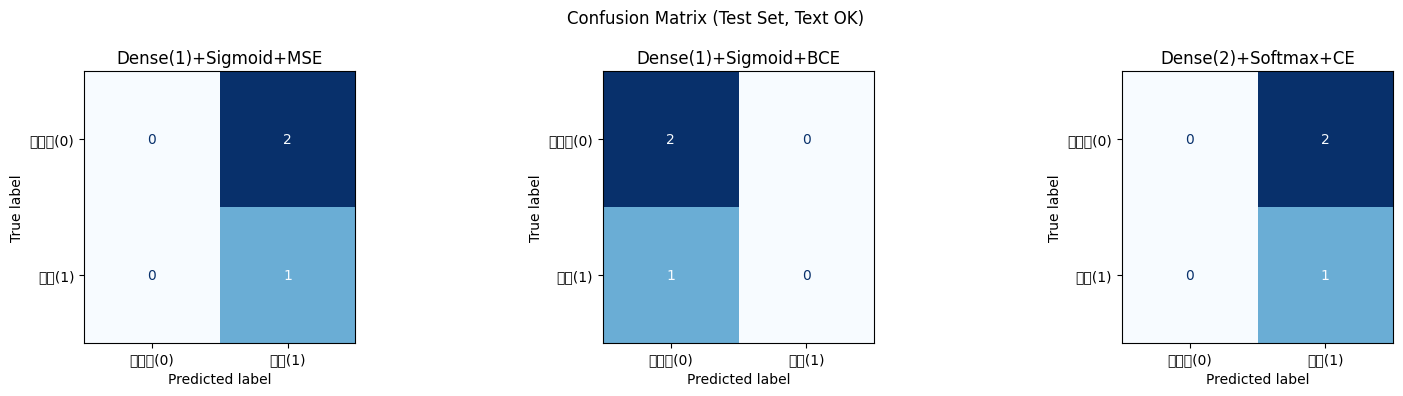

메트릭 요약:


,모델,정확도,정밀도,재현율,F1
0,Dense(1)+Sigmoid+MSE,0.333333,0.333333,1.0,0.5
1,Dense(1)+Sigmoid+BCE,0.666667,0.000000,0.0,0.0
2,Dense(2)+Softmax+CE,0.333333,0.333333,1.0,0.5


In [64]:
# 디버깅: 실행/분석을 위한 코드 추가 및 오류 상황 메시지 삽입

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, log_loss, confusion_matrix, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras.utils import to_categorical

import os

# 1. 데이터 로딩 with 에러 캐치
try:
    print("현재경로:", os.getcwd())
    data_path = DATA_DIR / "customer_purchase_binary.csv"
    print("파일존재여부:", os.path.exists(data_path))
    customers = pd.read_csv(data_path)
    print("CSV 로딩완료")
except Exception as e:
    print("CSV 로딩 실패:", e)
    raise

print("customers shape:", customers.shape)
display(customers.head(12))
display(customers.info())

# 2. customer_id 컬럼 제거
if "customer_id" in customers.columns:
    customers = customers.drop(columns=["customer_id"])
else:
    print("'customer_id' 컬럼이 없어 drop 하지 않음.")

target_col = "purchased"
categorical_cols = ["city", "device_type"]
numerical_cols = [c for c in customers.columns if c not in categorical_cols + [target_col]]

print("numerical_cols:", numerical_cols)
print("categorical_cols:", categorical_cols)
print("target_col:", target_col)

# 3. One-hot encoding (에러발생시 메시지)
try:
    # scikit-learn 1.2 이상에서는 sparse_output, 이전은 sparse
    import sklearn
    skl_ver = sklearn.__version__.split(".")
    if int(skl_ver[0]) > 1 or (int(skl_ver[0]) == 1 and int(skl_ver[1]) >= 2):
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    else:
        ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')
    cat_encoded = ohe.fit_transform(customers[categorical_cols])
    cat_encoded_df = pd.DataFrame(cat_encoded, columns=ohe.get_feature_names_out(categorical_cols), index=customers.index)
except Exception as e:
    print("OneHotEncoder 오류:", e)
    raise

try:
    features_df = pd.concat([customers[numerical_cols], cat_encoded_df], axis=1)
    feature_cols = features_df.columns
    print("features_df shape:", features_df.shape)
except Exception as e:
    print("features_df 생성 오류:", e)
    raise

# 4. Scaling
try:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(features_df)
except Exception as e:
    print("StandardScaler 오류:", e)
    raise

y = customers[target_col].values
print("feature_cols:", list(feature_cols))
print("y(타깃) 클래스 분포:\n", pd.Series(y).value_counts())

# 5. train/val/test split (stratify 적용)
try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
    )
    print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
    print("y_train 분포:", np.bincount(y_train.astype(int)))
    print("y_val 분포:", np.bincount(y_val.astype(int)))
    print("y_test 분포:", np.bincount(y_test.astype(int)))
except Exception as e:
    print("train/val/test split 오류:", e)
    raise

# 6. 모델 함수
def build_model_sigmoid_mse(input_dim):
    try:
        model = Sequential([
            Input(shape=(input_dim,)),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='mse', metrics=['mae'])
        return model
    except Exception as e:
        print("build_model_sigmoid_mse 오류:", e)
        raise

def build_model_sigmoid_bce(input_dim):
    try:
        model = Sequential([
            Input(shape=(input_dim,)),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model
    except Exception as e:
        print("build_model_sigmoid_bce 오류:", e)
        raise

def build_model_softmax_ce(input_dim):
    try:
        model = Sequential([
            Input(shape=(input_dim,)),
            Dense(16, activation='relu'),
            Dense(2, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model
    except Exception as e:
        print("build_model_softmax_ce 오류:", e)
        raise

# 7. 훈련 및 평가
try:
    print("[1] Dense(1)+Sigmoid+MSE 훈련 시작")
    model_mse = build_model_sigmoid_mse(X_train.shape[1])
    hist_mse = model_mse.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=0)
    y_pred_mse = (model_mse.predict(X_test) > 0.5).astype(int).flatten()
    print("MSE 모델 예측 완료")

    print("[2] Dense(1)+Sigmoid+BCE 훈련 시작")
    model_bce = build_model_sigmoid_bce(X_train.shape[1])
    hist_bce = model_bce.fit(X_train, y_train, epochs=30, validation_data=(X_val, y_val), verbose=0)
    y_pred_bce = (model_bce.predict(X_test) > 0.5).astype(int).flatten()
    print("BCE 모델 예측 완료")

    print("[3] Dense(2)+Softmax+CE 훈련 시작 (라벨 one-hot)")
    y_train_cat = to_categorical(y_train, 2)
    y_val_cat = to_categorical(y_val, 2)
    y_test_cat = to_categorical(y_test, 2)
    model_softmax = build_model_softmax_ce(X_train.shape[1])
    hist_softmax = model_softmax.fit(X_train, y_train_cat, epochs=30, validation_data=(X_val, y_val_cat), verbose=0)
    y_pred_softmax_raw = model_softmax.predict(X_test)
    y_pred_softmax = np.argmax(y_pred_softmax_raw, axis=1)
    print("Softmax CE 모델 예측 완료")
except Exception as e:
    print("모델 훈련/예측 오류:", e)
    raise

# 8. 시각화: Loss Curve (Seaborn)
try:
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    sns.lineplot(x=range(len(hist_mse.history['loss'])), y=hist_mse.history['loss'], label='Train Loss')
    sns.lineplot(x=range(len(hist_mse.history['val_loss'])), y=hist_mse.history['val_loss'], label='Val Loss')
    plt.title("Dense(1)+Sigmoid+MSE Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 2)
    sns.lineplot(x=range(len(hist_bce.history['loss'])), y=hist_bce.history['loss'], label='Train Loss')
    sns.lineplot(x=range(len(hist_bce.history['val_loss'])), y=hist_bce.history['val_loss'], label='Val Loss')
    plt.title("Dense(1)+Sigmoid+BCE Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 3, 3)
    sns.lineplot(x=range(len(hist_softmax.history['loss'])), y=hist_softmax.history['loss'], label='Train Loss')
    sns.lineplot(x=range(len(hist_softmax.history['val_loss'])), y=hist_softmax.history['val_loss'], label='Val Loss')
    plt.title("Dense(2)+Softmax+CE Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
except Exception as e:
    print("Loss Curve 시각화 오류:", e)
    raise

# 9. 시각화: Confusion Matrix & 주요 메트릭 비교표
try:
    from sklearn.metrics import ConfusionMatrixDisplay

    names = [
        'Dense(1)+Sigmoid+MSE',
        'Dense(1)+Sigmoid+BCE',
        'Dense(2)+Softmax+CE',
    ]
    y_preds = [y_pred_mse, y_pred_bce, y_pred_softmax]
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for i, (pred, name) in enumerate(zip(y_preds, names)):
        cm = confusion_matrix(y_test, pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['미구매(0)', '구매(1)'])
        disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
        axes[i].set_title(name)
    plt.suptitle("Confusion Matrix (Test Set, Text OK)")
    plt.tight_layout()
    plt.show()

    metrics_summary = []
    for name, pred in zip(names, y_preds):
        acc = accuracy_score(y_test, pred)
        pre = precision_score(y_test, pred, zero_division=0)
        rec = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)
        metrics_summary.append([name, acc, pre, rec, f1])
    metrics_df = pd.DataFrame(metrics_summary, columns=["모델", "정확도", "정밀도", "재현율", "F1"])
    print("메트릭 요약:")
    display(metrics_df)
except Exception as e:
    print("Confusion Matrix/Metric 표시 오류:", e)
    raise


### 내 답안 Q3

X column =  age	income	city	device_type	visit_count	cart_amount	days_since_last_visit
y column =  purchased
feature에서 제외할 column =  customer_id
categorical column =  city	device_type  purchased

필요한 전처리 =   city	device_type 은 dtype이 str이므로, 인코딩을 생각해주어야한다. 다만, 서울-대구, 대구-부산쌍처럼 거리관계로서 해석되면 안됨으로 이를 제거한 원핫인코딩방식을 체택하며, dtype 역시 마찬가지이다. // 

문제 유형 =  
split에서 stratify가 필요한 이유 =  

왜 Dense(1)+sigmoid인가 =  구매여부에 대한 예측이므로, 최종 분류는 인테거이자 0 or 1나와야한다. 따라서ㅡ, log로서 트레스홀드 0.5를 경계로 dens(1)의 아웃풋이 이상이면 1 이하면 0으로 분류해주는 엑티베이션이 필요하다.
Binary Cross Entropy는 어떤 확률을 벌주는가 =  실제 class에 낮은 확률을 주면 loss가 커진다.
accuracy가 높은데도 모델이 나쁠 수 있는 상황 =  도메인에 따라 다르나, 본 구매여부를 파악하는 도메인은, 구매를 하지 않았는데 했다고 예측하는 경우보다 구매를 했음에도 안했다고 예측하는 경우를 더 강하게 벌줘야한다. 리콜에 대해서 민감하게 봐야하며 따라서 산술평균이 아닌 조화 평균으으로 단순 어큐레이시와 프레시전, 리콜을 보기보다는 F1 계열로 메트릭을 설계해야한다. 단, DENSE1에 대해서 평가하는 것으로서, MACRO , WEIGTED 같은 다중분류 F1은 사용하지 않아도 된다.
precision, recall, F1의 차이 = 프레시젼(모델이 positive라고 찍은 것 중 진짜 positive 비율이다.) 리콜(실제 positive 중 모델이 잡아낸 비율이다.) F1(F1은 precision과 recall의 조화평균이다., 낮은쪽에 빈감하다.)
F1이 산술평균이 아니라 조화평균인 이유 =  F1=2⋅Precision+RecallPrecision⋅Recall ,그래서 한쪽만 좋은 모델을 높게 평가하지 않는다.

DNN output layer =  DENSE(1) + SIGMOID
activation =  SIGMOID
loss =  MSE , RL
metric 후보 = MAE , F1   /// 이때, 확률로서 이를 나타낼수도 있으며
accuracy 단독의 한계 = 정확도만 보지않는다.  

근거:
-


### Q4. 다중분류/순서형 target과 softmax CE 설계

`traffic_multiclass.csv`를 사용해 `congestion_level`을 예측한다.

label mapping은 다음과 같다.

```text
0 = 원활
1 = 보통
2 = 혼잡
3 = 매우 혼잡
```

답할 것:

```text
X column =
y column =
feature에서 제외할 column =
categorical column =
label mapping 보존이 필요한 이유 =
문제 유형 =
순서형 target으로 볼 수 있는 이유 =
왜 Dense(4)+softmax인가 =
sigmoid 여러 개와 softmax의 차이 =
sparse categorical cross entropy와 categorical cross entropy의 차이 =
순서형 target을 softmax 다중분류로 처리할 때의 장점 =
순서형 target을 softmax 다중분류로 처리할 때의 한계 =
cost matrix는 무엇을 보완하는가 =
순서형 feature라면 raw integer, one-hot, cumulative encoding 중 무엇을 고려할 수 있는가 =
정규화가 ordinal code의 거리 가정을 없애는가 =
기본 DNN output layer =
activation =
loss =
metric 후보 =
회귀처럼 풀 때의 위험 =
```


In [12]:
# 힌트:
# traffic = pd.read_csv(DATA_DIR / "traffic_multiclass.csv")
# traffic.head()
# traffic["congestion_level"].value_counts()
# congestion_level의 숫자가 실제 거리/양인지 class code인지 판단하라.
# weekday, weather는 어떤 dtype인지 확인하라.
# class가 4개일 때 output unit 수를 생각하라.
# sigmoid 여러 개는 multi-label, softmax는 single-label multi-class에 가깝다는 차이를 떠올려라.


### 내 답안 Q4

X column =  
y column =  
feature에서 제외할 column =  
categorical column =  
label mapping 보존이 필요한 이유 =  

문제 유형 =  
순서형 target으로 볼 수 있는 이유 =  

왜 Dense(4)+softmax인가 =  
sigmoid 여러 개와 softmax의 차이 =  
sparse categorical cross entropy와 categorical cross entropy의 차이 =  
순서형 target을 softmax 다중분류로 처리할 때의 장점 =  
순서형 target을 softmax 다중분류로 처리할 때의 한계 =  
cost matrix는 무엇을 보완하는가 =  

순서형 feature라면 raw integer, one-hot, cumulative encoding 중 무엇을 고려할 수 있는가 =  
정규화가 ordinal code의 거리 가정을 없애는가 =  

기본 DNN output layer =  
activation =  
loss =  
metric 후보 =  
회귀처럼 풀 때의 위험 =  

근거:
-


### Q5. validation/test와 compile/fit/evaluate 역할 구분

다음 흐름을 보고 각 단계의 역할을 설명하라.

```text
1. train/validation/test를 나눈다.
2. model = Sequential(...)
3. model.compile(optimizer=..., loss=..., metrics=[...])
4. model.fit(X_train, y_train, validation_data=(X_val, y_val))
5. model.evaluate(X_test, y_test)
```

답할 것:

```text
train set의 역할 =
validation set의 역할 =
test set의 역할 =
validation을 test처럼 반복 사용하면 생기는 문제 =
Sequential/add의 역할 =
compile은 구조를 학습시키는 단계인가, 학습 기준을 붙이는 단계인가 =
model.compile()의 역할 =
fit 내부에서 반복되는 과정 =
model.fit()의 역할 =
model.evaluate()의 역할 =
validation은 왜 test와 다른가 =
loss와 metric은 왜 분리해서 보는가 =
loss와 metric의 차이 =
```


In [13]:
# 힌트:
# train은 파라미터 학습에 직접 사용된다.
# validation은 실험 중 모델 선택과 일반화 확인에 사용된다.
# test는 마지막 최종 평가용으로 남긴다.
# compile, fit, evaluate가 각각 무엇을 연결하거나 수행하는지 구분하라.
# loss는 gradient 계산에 직접 쓰이고, metric은 사람이 해석하는 지표인지 생각하라.


### 내 답안 Q5

train set의 역할 =  
validation set의 역할 =  
test set의 역할 =  
validation을 test처럼 반복 사용하면 생기는 문제 =  

Sequential/add의 역할 =  
compile은 구조를 학습시키는 단계인가, 학습 기준을 붙이는 단계인가 =  
model.compile()의 역할 =  
fit 내부에서 반복되는 과정 =  
model.fit()의 역할 =  
model.evaluate()의 역할 =  

validation은 왜 test와 다른가 =  
loss와 metric은 왜 분리해서 보는가 =  
loss와 metric의 차이 =  

근거:
-


### Q6. 통합 설계 문제

아래 세 가지 프로젝트 중 하나를 골라 전체 설계를 작성하라.

```text
A. house_price_regression.csv로 price_million 예측
B. customer_purchase_binary.csv로 purchased 예측
C. traffic_multiclass.csv로 congestion_level 예측
```

답할 것:

```text
선택한 프로젝트 =
문제 유형 =
X/y 분리 =
제외할 column =
encoding/scaling 계획 =
split 계획 =
leakage 방지 원칙 =
DNN output/activation/loss/metric =
왜 그 output/loss/metric을 고르는가 =
validation/test 사용 계획 =
회귀 프로젝트를 선택했다면 MSE/MAE/RMSE와 inverse_transform 해석 =
이진분류 프로젝트를 선택했다면 accuracy/F1/precision/recall 선택 이유 =
순서형 target을 선택했다면 softmax CE와 ordinal/cost-sensitive 접근 비교 =
최종 한 문장 요약 =
```


In [14]:
# 힌트:
# 하나만 골라서 끝까지 설계한다.
# X/y, 제외 column, encoding, scaling, split 순서를 연결해서 쓴다.
# output/loss/metric은 선택한 문제 유형에 맞게 고른다.
# 단순히 이름만 쓰지 말고 y의 의미에서 왜 그렇게 고르는지 설명하라.
# test set은 마지막 평가에만 쓰는지 확인하라.


### 내 답안 Q6

선택한 프로젝트 =  
문제 유형 =  
X/y 분리 =  
제외할 column =  
encoding/scaling 계획 =  
split 계획 =  
leakage 방지 원칙 =  
DNN output/activation/loss/metric =  
왜 그 output/loss/metric을 고르는가 =  
validation/test 사용 계획 =  

회귀 프로젝트를 선택했다면 MSE/MAE/RMSE와 inverse_transform 해석 =  
이진분류 프로젝트를 선택했다면 accuracy/F1/precision/recall 선택 이유 =  
순서형 target을 선택했다면 softmax CE와 ordinal/cost-sensitive 접근 비교 =  

최종 한 문장 요약 =  

근거:
-
